In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [3]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
!unzip -q rps.zip

--2026-05-18 20:10:21--  https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘rps.zip’

rps.zip             100%[===================>] 191.38M   121MB/s    in 1.6s    

2026-05-18 20:10:22 (121 MB/s) - ‘rps.zip’ saved [200682221/200682221]



In [4]:
transform = transforms.Compose([

    transforms.Resize((128,128)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.5,0.5,0.5],
        [0.5,0.5,0.5]
    )
])

In [5]:
dataset = datasets.ImageFolder(
    root='rps',
    transform=transform
)

print(dataset.classes)

['paper', 'rock', 'scissors']


In [6]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [8]:
class CNNModel(nn.Module):

    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 3)

        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

In [9]:
model = CNNModel().to(device)

print(model)

CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Drop

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
epochs = 15

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0

patience = 3
counter = 0

In [12]:
for epoch in range(epochs):

    # ================= TRAIN =================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    # ================= VALIDATION =================

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)

    val_accuracy = 100 * correct / total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}]')

    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%')

    print(f'Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%')

    # ================= SAVE BEST MODEL =================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(model.state_dict(), 'best_model.pth')

        print('✅ Best Model Saved')

        counter = 0

    else:

        counter += 1

        print(f'⚠ No Improvement {counter}/{patience}')

    # ================= EARLY STOPPING =================

    if counter >= patience:

        print('🛑 Early Stopping')

        break

    print('-' * 50)

Epoch [1/15]
Train Loss: 2.9579 | Train Accuracy: 52.44%
Val Loss: 0.5697 | Val Accuracy: 84.92%
✅ Best Model Saved
--------------------------------------------------
Epoch [2/15]
Train Loss: 0.4069 | Train Accuracy: 85.15%
Val Loss: 0.1477 | Val Accuracy: 96.83%
✅ Best Model Saved
--------------------------------------------------
Epoch [3/15]
Train Loss: 0.1905 | Train Accuracy: 93.59%
Val Loss: 0.0660 | Val Accuracy: 98.41%
✅ Best Model Saved
--------------------------------------------------
Epoch [4/15]
Train Loss: 0.1436 | Train Accuracy: 95.63%
Val Loss: 0.0354 | Val Accuracy: 99.21%
✅ Best Model Saved
--------------------------------------------------
Epoch [5/15]
Train Loss: 0.0794 | Train Accuracy: 97.68%
Val Loss: 0.0366 | Val Accuracy: 98.94%
⚠ No Improvement 1/3
--------------------------------------------------
Epoch [6/15]
Train Loss: 0.0762 | Train Accuracy: 97.34%
Val Loss: 0.0200 | Val Accuracy: 99.47%
✅ Best Model Saved
-----------------------------------------------

In [13]:
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [14]:
model.eval()

test_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

test_loss /= len(test_loader)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Loss: 0.0085
Test Accuracy: 99.74%


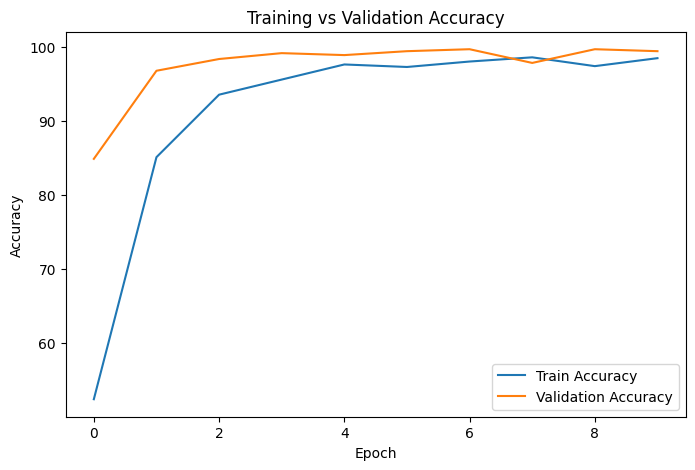

In [15]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')

plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

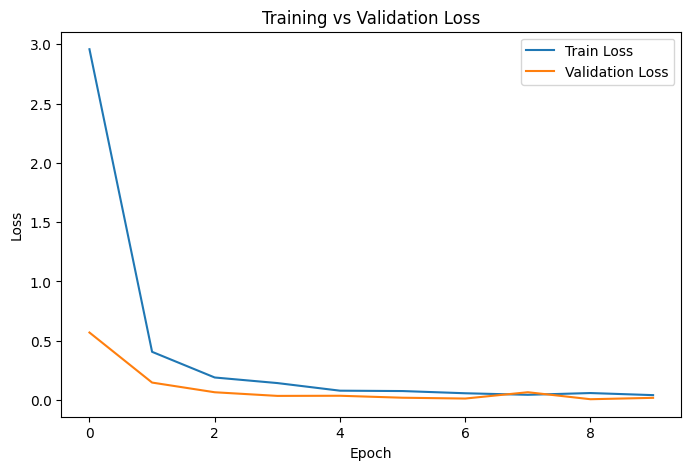

In [16]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [17]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes
))

              precision    recall  f1-score   support

       paper       1.00      0.99      1.00       132
        rock       1.00      1.00      1.00       109
    scissors       0.99      1.00      1.00       137

    accuracy                           1.00       378
   macro avg       1.00      1.00      1.00       378
weighted avg       1.00      1.00      1.00       378



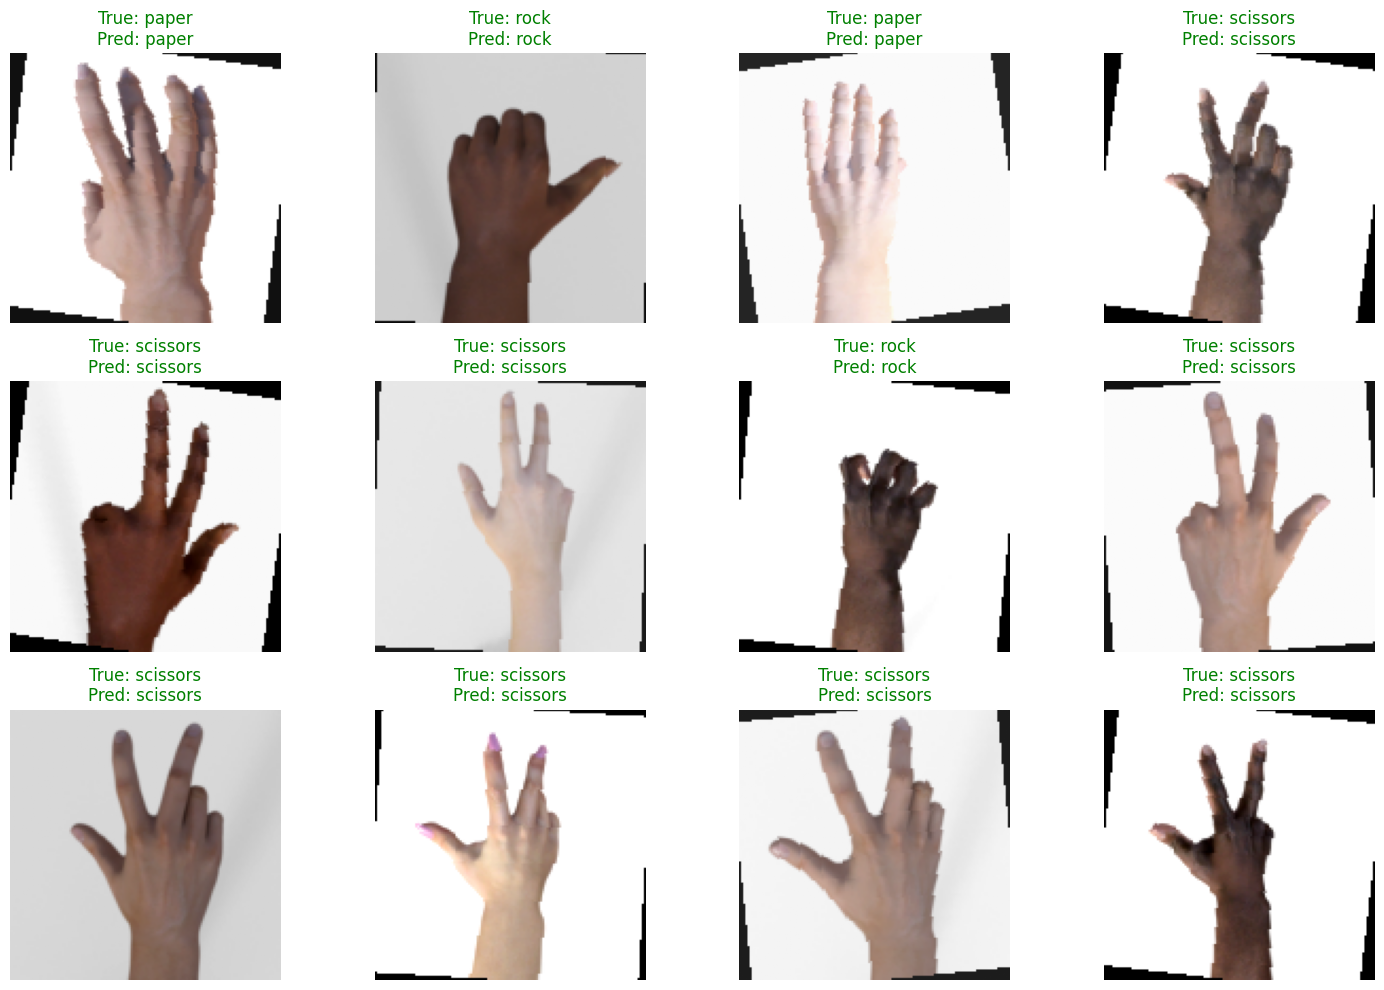

In [18]:
classes = dataset.classes

model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

plt.figure(figsize=(15,10))

for i in range(12):

    plt.subplot(3,4,i+1)

    img = images[i].permute(1,2,0).numpy()

    img = (img * 0.5) + 0.5

    plt.imshow(img)

    true_label = classes[labels[i]]
    pred_label = classes[predicted[i]]

    if true_label == pred_label:

        color = 'green'

    else:

        color = 'red'

    plt.title(
        f'True: {true_label}\nPred: {pred_label}',
        color=color
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [40]:
model_sgd = CNNModel().to(device)

In [41]:
criterion = nn.CrossEntropyLoss()

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.0001,
    momentum=0.9
)

In [42]:
epochs = 15

train_losses_sgd = []
val_losses_sgd = []

train_accuracies_sgd = []
val_accuracies_sgd = []

best_val_accuracy_sgd = 0

patience = 5
counter = 0

In [43]:
for epoch in range(epochs):

    # ================= TRAIN =================

    model_sgd.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer_sgd.zero_grad()

        outputs = model_sgd(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_sgd.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    train_losses_sgd.append(train_loss)

    train_accuracies_sgd.append(train_accuracy)

    # ================= VALIDATION =================

    model_sgd.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model_sgd(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)

    val_accuracy = 100 * correct / total

    val_losses_sgd.append(val_loss)

    val_accuracies_sgd.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}]')

    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%')

    print(f'Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%')

    # ================= SAVE BEST MODEL =================

    if val_accuracy > best_val_accuracy_sgd:

        best_val_accuracy_sgd = val_accuracy

        torch.save(model_sgd.state_dict(), 'best_model_sgd.pth')

        print('✅ Best SGD Model Saved')

        counter = 0

    else:

        counter += 1

        print(f'⚠ No Improvement {counter}/{patience}')

    # ================= EARLY STOPPING =================

    if counter >= patience:

        print('🛑 Early Stopping')

        break

    print('-' * 50)

Epoch [1/15]
Train Loss: 0.9960 | Train Accuracy: 50.51%
Val Loss: 0.8693 | Val Accuracy: 55.82%
✅ Best SGD Model Saved
--------------------------------------------------
Epoch [2/15]
Train Loss: 0.7061 | Train Accuracy: 74.26%
Val Loss: 0.5584 | Val Accuracy: 87.57%
✅ Best SGD Model Saved
--------------------------------------------------
Epoch [3/15]
Train Loss: 0.5141 | Train Accuracy: 85.15%
Val Loss: 0.4099 | Val Accuracy: 90.74%
✅ Best SGD Model Saved
--------------------------------------------------
Epoch [4/15]
Train Loss: 0.3656 | Train Accuracy: 90.87%
Val Loss: 0.2756 | Val Accuracy: 95.77%
✅ Best SGD Model Saved
--------------------------------------------------
Epoch [5/15]
Train Loss: 0.3004 | Train Accuracy: 92.46%
Val Loss: 0.2185 | Val Accuracy: 97.62%
✅ Best SGD Model Saved
--------------------------------------------------
Epoch [6/15]
Train Loss: 0.2408 | Train Accuracy: 94.84%
Val Loss: 0.1838 | Val Accuracy: 97.88%
✅ Best SGD Model Saved
-------------------------

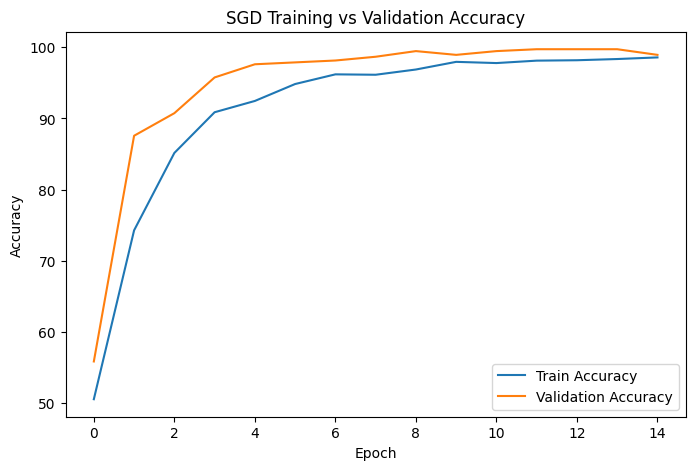

In [46]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies_sgd, label='Train Accuracy')

plt.plot(val_accuracies_sgd, label='Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('SGD Training vs Validation Accuracy')

plt.legend()

plt.show()

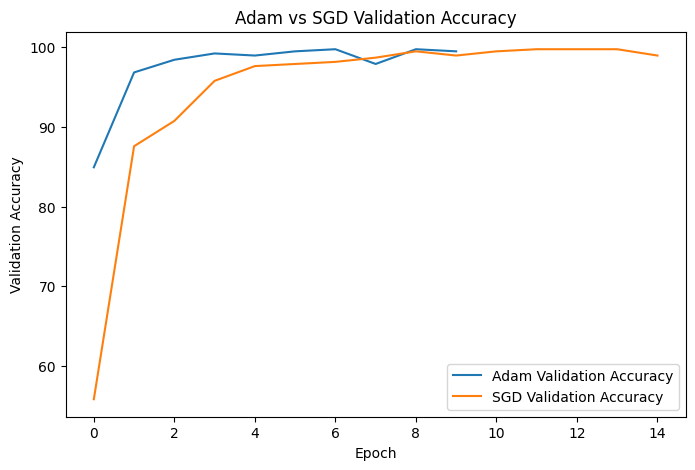

In [44]:
plt.figure(figsize=(8,5))

plt.plot(val_accuracies, label='Adam Validation Accuracy')
plt.plot(val_accuracies_sgd, label='SGD Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Adam vs SGD Validation Accuracy')
plt.legend()

plt.show()

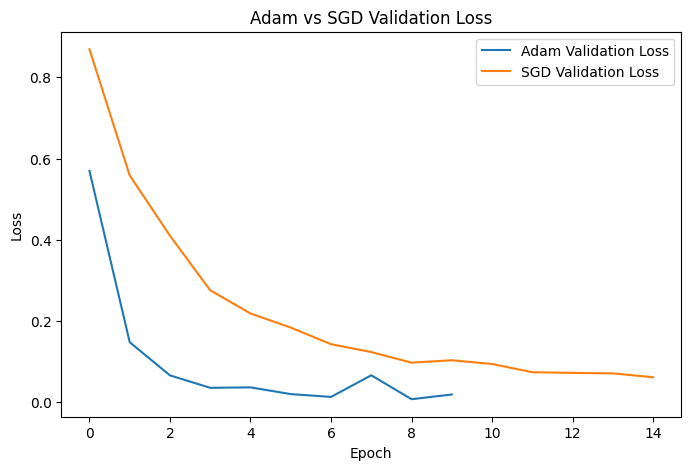

In [45]:
plt.figure(figsize=(8,5))

plt.plot(val_losses, label='Adam Validation Loss')
plt.plot(val_losses_sgd, label='SGD Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam vs SGD Validation Loss')
plt.legend()

plt.show()